# Distribución de firmas y productividad

- Primero, limpiamos y armonizamos el df que decargamos del campus. Hicimos lo que en la jerga se conoce cómo parsear. Problemas en US y Argentina, que tenían intervalos de empleados como columna y así agrupaban la cantidad de firmas. 
- Segundo, cargamos los datos y generamos nuevas columnas que nos permitirán calcular manualmente la CDF y la probabilidad 'de la cola'. 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# Cargamos los datos desde un Excel ya "armonizado" en términos de sus columnas entre hojas


file = r"C:\Users\Juan\Desktop\trabajos code - python\macro develop\deber4\Normalizada_entero_sizefirmsdist.xlsx"

df_us  = pd.read_excel(file, sheet_name="US_valor_medio_entero")
df_esp = pd.read_excel(file, sheet_name="España")
df_ind = pd.read_excel(file, sheet_name="India")
df_arg = pd.read_excel(file, sheet_name="Argentina_valor_medio_entero")

for df in [df_us, df_esp, df_ind, df_arg]:
    df.rename(columns={"Empleados": "n", "Empresas": "freq"}, inplace=True)



## Survival Funciton o Probabilidad Acumulada en el extremo derecho de la distribución (P(N > n))
#
# P(N > n) = fracción de firmas con más de n empleados.
# En log-log, si la distribución es Pareto esto es una recta.
#
# Pasos seguidos:
#   1. Eliminar filas con NaN (algunos Excel tienen filas de total al final)
#   2. Ordenar de menor a mayor
#   3. CDF acumulada desde abajo
#   4. P(N > n) = 1 - CDF
#   5. Sacar puntos donde P = 0 (log no definido)
#   6. Tomar logaritmos


def calcular_survival(df):
    df = df.copy()
    df = df.dropna()                             # elimina filas con NaN o totales sueltos
    df = df.sort_values("n").reset_index(drop=True)
    total        = df["freq"].sum()
    df["CDF"]    = df["freq"].cumsum() / total   # fracción acumulada hasta n
    df["P_tail"] = 1 - df["CDF"]                # fracción de firmas por encima de n
    df           = df[df["P_tail"] > 0]          # sacamos donde P = 0
    df["log_n"]  = np.log(df["n"])
    df["log_P"]  = np.log(df["P_tail"])
    return df

df_us  = calcular_survival(df_us)
df_esp = calcular_survival(df_esp)
df_ind = calcular_survival(df_ind)
df_arg = calcular_survival(df_arg)

df_us.head()

,n,freq,CDF,P_tail,log_n,log_P
0,3,2669870,0.542031,0.457969,1.098612,-0.780953
1,7,1021210,0.749354,0.250646,1.945910,-1.383714
2,12,406691,0.831920,0.168080,2.484907,-1.783312
3,17,210396,0.874634,0.125366,2.833213,-2.076515
4,22,130006,0.901027,0.098973,3.091042,-2.312909


Acá realizamos ya la estimación por OLS con el df. Renombramos variables pero aclaramos en el mismo code a qué nos referimos.

In [7]:
## Estimación de ζ por OLS 
#
# Pareto implica:  ln P(N > n) = -γ · ln(n) + constante
# OLS nos da la pendiente = -γ   →   γ = -pendiente
# ζ = γ / (1-α)
#
# PTF agregada del modelo:  Z = (γ/(γ-1))^(1-α)   si γ > 1 (C.N. rtado.ej 1 inciso c)   

ALPHA = 2/3

def estimar_zeta(df, nombre):
    slope, intercept, r, _, _ = stats.linregress(df["log_n"], df["log_P"])
    gamma = -slope
    zeta  = gamma / (1 - ALPHA)

    if gamma > 1:
        Z     = (gamma / (gamma - 1)) ** (1 - ALPHA)
        Z_str = f"{Z:.3f}"
    else:
        Z     = np.nan
        Z_str = "n/a (γ ≤ 1)"

    print(f"{nombre:<12}  γ = {gamma:.3f}   ζ = {zeta:.3f}   Z = {Z_str}   R² = {r**2:.3f}")
    return slope, intercept, gamma, zeta, Z

print(f"\n{'País':<12}  {'γ':>8}   {'ζ':>8}   {'Z':>10}   {'R²':>6}")
print("-" * 58)
s_us,  i_us,  g_us,  z_us,  Z_us  = estimar_zeta(df_us,  "USA")
s_esp, i_esp, g_esp, z_esp, Z_esp = estimar_zeta(df_esp, "España")
s_ind, i_ind, g_ind, z_ind, Z_ind = estimar_zeta(df_ind, "India")
s_arg, i_arg, g_arg, z_arg, Z_arg = estimar_zeta(df_arg, "Argentina")


País                 γ          ζ            Z       R²
----------------------------------------------------------
USA           γ = 1.032   ζ = 3.097   Z = 3.169   R² = 0.998
España        γ = 1.194   ζ = 3.582   Z = 1.833   R² = 0.995
India         γ = 1.631   ζ = 4.892   Z = 1.372   R² = 0.986
Argentina     γ = 0.994   ζ = 2.983   Z = n/a (γ ≤ 1)   R² = 0.983


Graficamos los resultados encontrados

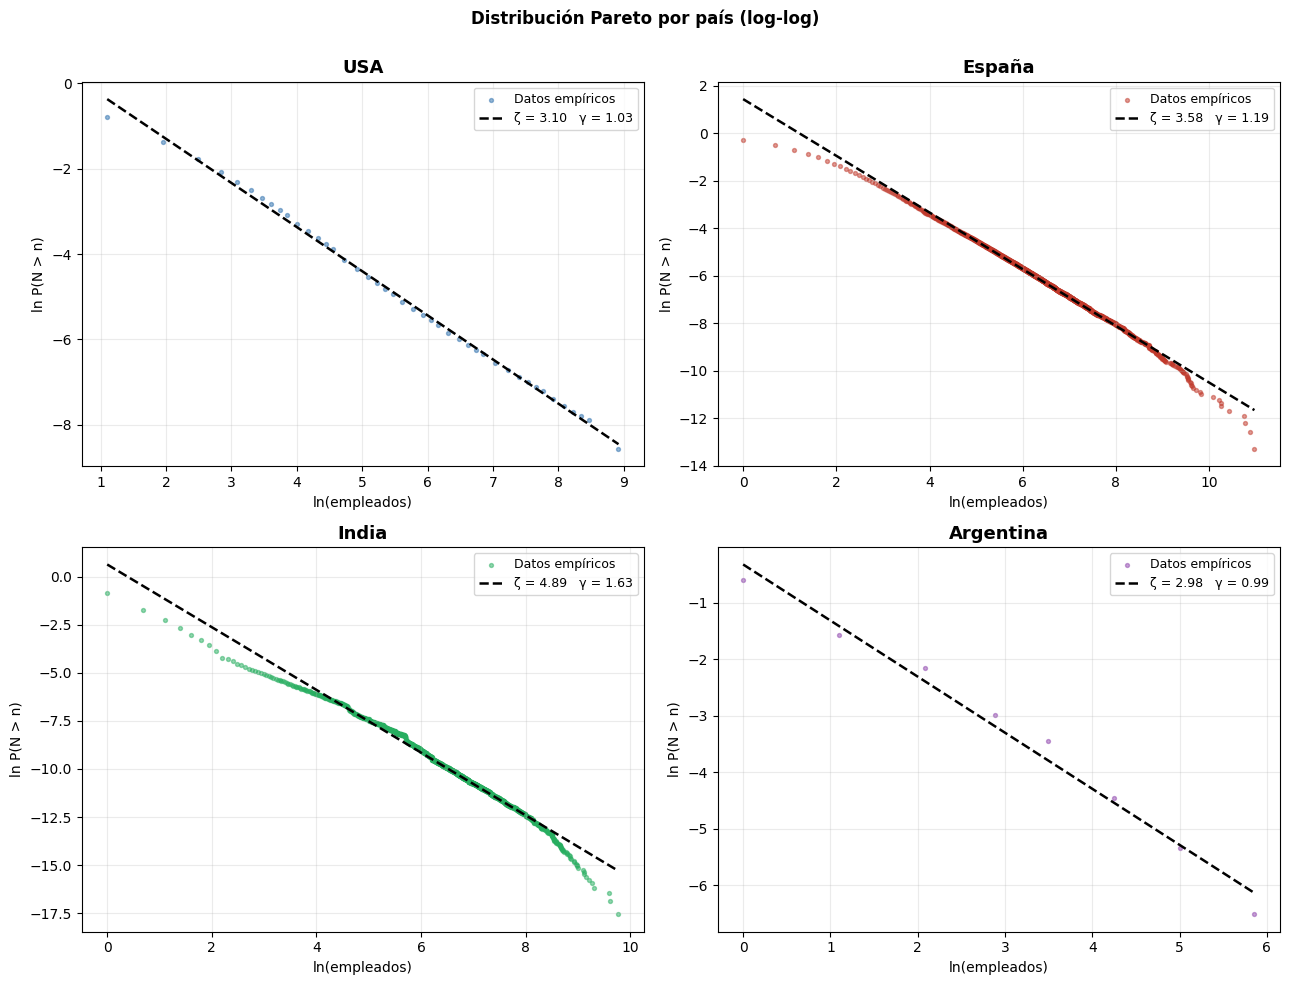

In [8]:
# Graficamos las estimaciones anteriores: log-log con ajuste Pareto


fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

paises = [
    ("USA",       df_us,  s_us,  i_us,  g_us,  z_us,  "#2c6fad"),
    ("España",    df_esp, s_esp, i_esp, g_esp, z_esp, "#c0392b"),
    ("India",     df_ind, s_ind, i_ind, g_ind, z_ind, "#27ae60"),
    ("Argentina", df_arg, s_arg, i_arg, g_arg, z_arg, "#8e44ad"),
]

for ax, (nombre, df, slope, intercept, gamma, zeta, color) in zip(axes, paises):

    ax.scatter(df["log_n"], df["log_P"],
               s=8, alpha=0.5, color=color, label="Datos empíricos")

    x_line = np.linspace(df["log_n"].min(), df["log_n"].max(), 200)
    ax.plot(x_line, intercept + slope * x_line,
            color="black", linewidth=1.8, linestyle="--",
            label=f"ζ = {zeta:.2f}   γ = {gamma:.2f}")

    ax.set_title(nombre, fontsize=13, fontweight="bold")
    ax.set_xlabel("ln(empleados)", fontsize=10)
    ax.set_ylabel("ln P(N > n)", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    "Distribución Pareto por país (log-log)\n"
    , fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("pareto_paises.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# Analizamos la PTF agregada y la brecha entre países (respecto con USA)
#
# Z_pais / Z_usa = fracción del nivel de PTF de USA que explica
# la distribución de firmas. El resto → misallocation, capital, etc.


print("\n" + "="*60)
print("PTF agregada Z y brecha con USA")
print("="*60)
print(f"{'País':<12}  {'Z':>7}  {'Z/Z_usa':>10}  {'Sin explicar':>14}")
print("-"*60)

for nombre, Z in [("USA", Z_us), ("España", Z_esp), ("India", Z_ind), ("Argentina", Z_arg)]:
    if not np.isnan(Z):
        ratio  = Z / Z_us
        brecha = (1 - ratio) * 100
        print(f"{nombre:<12}  {Z:>7.3f}  {ratio:>10.3f}  {brecha:>13.1f}%")
    else:
        print(f"{nombre:<12}  {'n/a':>7}  {'n/a':>10}  γ ≤ 1, no computable")

print("="*60)
print("\nLa brecha sin explicar se puede atribuir a:")
print("  - Misallocation de recursos")
print("  - Costos de entrada regulatorios")
print("  - Diferencias en capital físico y humano")


PTF agregada Z y brecha con USA
País                Z     Z/Z_usa    Sin explicar
------------------------------------------------------------
USA             3.169       1.000            0.0%
España          1.833       0.578           42.2%
India           1.372       0.433           56.7%
Argentina         n/a         n/a  γ ≤ 1, no computable

La brecha sin explicar se puede atribuir a:
  - Misallocation de recursos
  - Costos de entrada regulatorios
  - Diferencias en capital físico y humano
